<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/SQ4DS_Lecture3.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 6.  Inferential Statistics,Sampling Distributions and Hypothesis Testing
### Statistics & Quantitative Methods for Data Science

**Where we've been:** Weeks 1-2 covered *descriptive* statistics (summarizing data we have) and probability foundations (distributions, sampling, the CLT).

**Where we're going:** *Inferential* statistics — using a **sample** to draw conclusions about a **population** we can't fully observe, and being honest about how uncertain those conclusions are.

**This notebook:**
1. Descriptive vs. inferential statistics
2. Sampling techniques and Distribution
3. Central Limit Theorem
4. Point estimates
5. Confidence intervals for a mean
6. Confidence intervals for a proportion
7. What "95% confidence" actually means (simulation)
8. Sample size & margin of error
9. Hypothesis testing
10. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


---
# 1. Descriptive vs. inferential statistics

| | Descriptive | Inferential |
|---|---|---|
| Question | "What does *this* data look like?" | "What can I conclude about the *population* from this sample?" |
| Tools | mean, median, std, histograms | confidence intervals, hypothesis tests, p-values |
| Certainty | Exact (it's just arithmetic on data you have) | Always comes with **uncertainty** — a margin of error |

The 891 Titanic passengers in our dataset are themselves a **sample** of "everyone who could conceivably have been on a similar ship." Every number we compute from them is an *estimate*, not a certainty.

---
# 2. Sampling techniques

We rarely observe an entire population — we work with a **sample**. *How* we draw that sample determines whether it fairly represents the population. We'll treat the full Titanic dataset (891 passengers) as our "population" and draw samples from it.

### 4.1 Simple random sampling
Every member of the population has an equal chance of being selected — the baseline, unbiased method.

In [ ]:
population = titanic.copy()
simple_sample = population.sample(n=100, random_state=1)   # without replacement by default

print(f"Population survival rate: {population['survived'].mean():.3f}")
print(f"Sample survival rate:     {simple_sample['survived'].mean():.3f}")

Population survival rate: 0.384
Sample survival rate:     0.390


### 4.2 Sampling with vs. without replacement

- **Without replacement**: each individual can be selected only once (typical for surveys — you don't ask the same person twice)
- **With replacement**: an individual can be selected multiple times (used for bootstrap resampling, Part 7)

In [ ]:
without_repl = population.sample(n=50, replace=False, random_state=1)
with_repl    = population.sample(n=50, replace=True, random_state=1)

print(f"Without replacement — unique passengers selected: {without_repl.index.nunique()} / 50")
print(f"With replacement    — unique passengers selected: {with_repl.index.nunique()} / 50  (some repeats)")

Without replacement — unique passengers selected: 50 / 50
With replacement    — unique passengers selected: 50 / 50  (some repeats)


### 4.3 Stratified sampling

Split the population into homogeneous **strata** (here, passenger class) and sample proportionally from each — guarantees every subgroup is represented in the right proportion, reducing variance versus simple random sampling.

In [ ]:
def stratified_sample(df, strata_col, frac):
    parts = [g.sample(frac=frac, random_state=1) for _, g in df.groupby(strata_col)]
    return pd.concat(parts)

strat_sample = stratified_sample(population, 'class', frac=0.15)

comparison = pd.DataFrame({
    'Population %': population['class'].value_counts(normalize=True),
    'Simple random sample %': simple_sample['class'].value_counts(normalize=True),
    'Stratified sample %': strat_sample['class'].value_counts(normalize=True),
}).round(3)
comparison

,Population %,Simple random sample %,Stratified sample %
class,,,
Third,0.551,0.55,0.552
First,0.242,0.23,0.239
Second,0.207,0.22,0.209


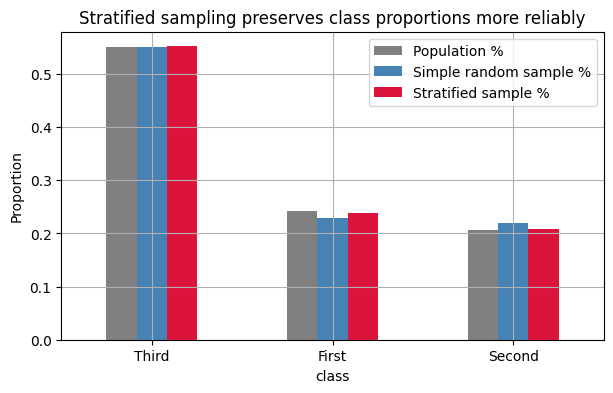

In [ ]:
comparison.plot(kind='bar', figsize=(7,4), color=['gray','steelblue','crimson'])
plt.title('Stratified sampling preserves class proportions more reliably')
plt.ylabel('Proportion'); plt.xticks(rotation=0)
plt.show()

### 4.4 Systematic sampling

Pick every $k$-th individual from a (randomly ordered) list. Simple to implement, and equivalent to simple random sampling as long as there's no hidden periodic pattern in the ordering.

In [ ]:
k = 9   # every 9th passenger -> roughly 100 of 891
shuffled = population.sample(frac=1, random_state=7).reset_index(drop=True)  # randomize order first
systematic_sample = shuffled.iloc[::k]

print(f"Systematic sample size: {len(systematic_sample)}")
print(f"Systematic sample survival rate: {systematic_sample['survived'].mean():.3f}")

Systematic sample size: 99
Systematic sample survival rate: 0.384


### 4.5 Cluster sampling

Split the population into **clusters** (naturally occurring groups), randomly select a *few whole clusters*, and use every member of those clusters. Cheaper when the population is geographically or structurally grouped — but less precise than stratified sampling, since clusters may not be perfectly representative.

In [ ]:
# Treat embarkation port as natural "clusters"
clusters = population['embark_town'].dropna().unique()
chosen_clusters = np.random.choice(clusters, size=2, replace=False)
cluster_sample = population[population['embark_town'].isin(chosen_clusters)]

print(f"Chosen clusters: {chosen_clusters}")
print(f"Cluster sample size: {len(cluster_sample)}")
print(f"Cluster sample survival rate: {cluster_sample['survived'].mean():.3f}")
print(f"(True population rate: {population['survived'].mean():.3f} — cluster sampling can drift further from it)")

Chosen clusters: ['Southampton' 'Cherbourg']
Cluster sample size: 812
Cluster sample survival rate: 0.382
(True population rate: 0.384 — cluster sampling can drift further from it)


### 4.6 Summary of sampling techniques

| Technique | How it works | Best when |
|---|---|---|
| Simple random | Every unit equally likely | No known subgroup structure |
| Stratified | Sample proportionally within known subgroups | Subgroups differ meaningfully, want guaranteed representation |
| Systematic | Every k-th unit from a randomized list | Need a simple, fast method with no periodicity risk |
| Cluster | Randomly pick whole groups, use all members | Population naturally grouped, individual sampling is costly |
| Bootstrap (with replacement) | Resample the *sample itself* many times | Estimating the sampling distribution of a statistic (Part 7) |

---
# 3. Sampling distributions & standard error

If we repeatedly draw samples and compute a statistic (e.g. the mean) each time, that statistic itself has a distribution — the **sampling distribution**. Its spread is measured by the **standard error**:

$$SE = \frac{\sigma}{\sqrt{n}}$$

Larger samples give a *less variable* sample mean — this is the seed of the Central Limit Theorem.

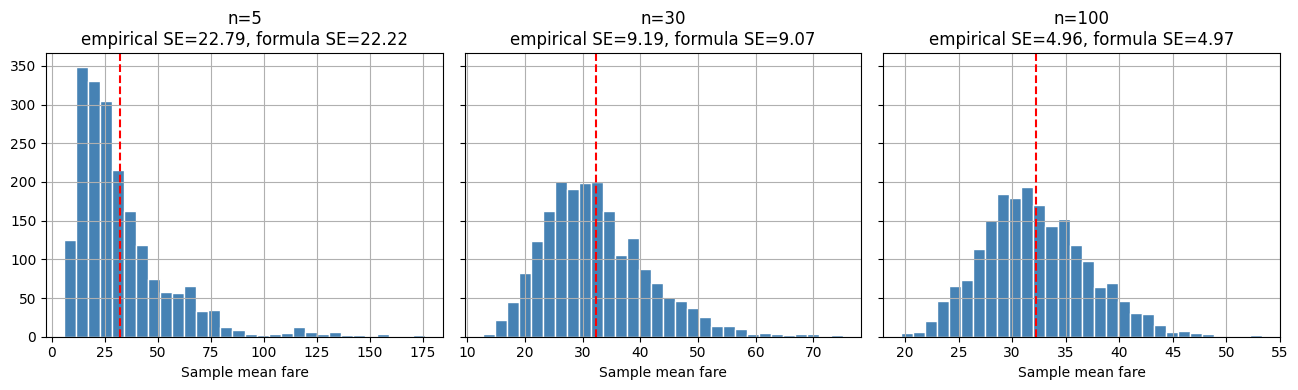

In [ ]:
fare_population = titanic['fare'].dropna()
pop_mean, pop_std = fare_population.mean(), fare_population.std()

sample_sizes = [5, 30, 100]
fig, axes = plt.subplots(1, 3, figsize=(13,4), sharey=True)

for ax, n in zip(axes, sample_sizes):
    sample_means = [fare_population.sample(n, replace=True, random_state=i).mean() for i in range(2000)]
    ax.hist(sample_means, bins=30, color='steelblue', edgecolor='white')
    se_empirical = np.std(sample_means)
    se_formula   = pop_std / np.sqrt(n)
    ax.axvline(pop_mean, color='red', linestyle='--')
    ax.set_title(f'n={n}\nempirical SE={se_empirical:.2f}, formula SE={se_formula:.2f}')
    ax.set_xlabel('Sample mean fare')

plt.tight_layout()
plt.show()

As sample size grows, the sampling distribution of the mean gets **narrower** (smaller SE) — bigger samples give more precise estimates, shrinking proportionally to $1/\sqrt{n}$, not $1/n$ (diminishing returns).

---
# 4. The Central Limit Theorem (CLT)

> **If you draw sufficiently large random samples from *any* population with finite variance and compute their means, the distribution of those sample means approaches a Normal distribution — regardless of the shape of the original population.**

$$\bar{X} \sim \text{approximately Normal}\left(\mu, \frac{\sigma^2}{n}\right) \text{ as } n \to \infty$$

This is why the Normal distribution is everywhere in statistics: it's the destination that *averages* converge to, even when individual observations don't look Normal at all.

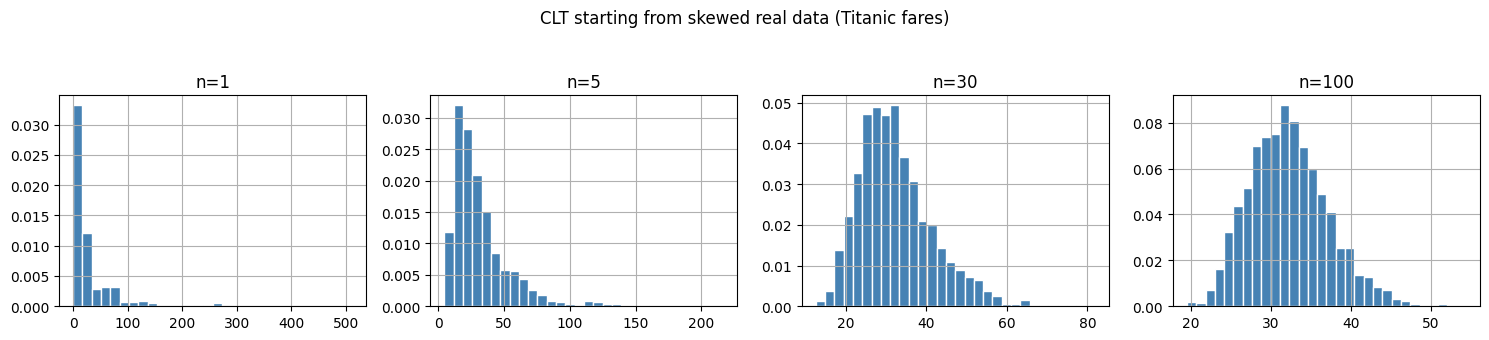

In [ ]:
def clt_demo(population_sampler, title, sample_sizes=(1, 5, 30, 100)):
    fig, axes = plt.subplots(1, len(sample_sizes), figsize=(15, 3.2))
    for ax, n in zip(axes, sample_sizes):
        means = [population_sampler(n).mean() for _ in range(3000)]
        ax.hist(means, bins=30, density=True, color='steelblue', edgecolor='white')
        ax.set_title(f'n={n}')
    fig.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()

# 1. Start from a badly-skewed population: Titanic fares (heavy right skew)
clt_demo(lambda n: fare_population.sample(n, replace=True), "CLT starting from skewed real data (Titanic fares)")

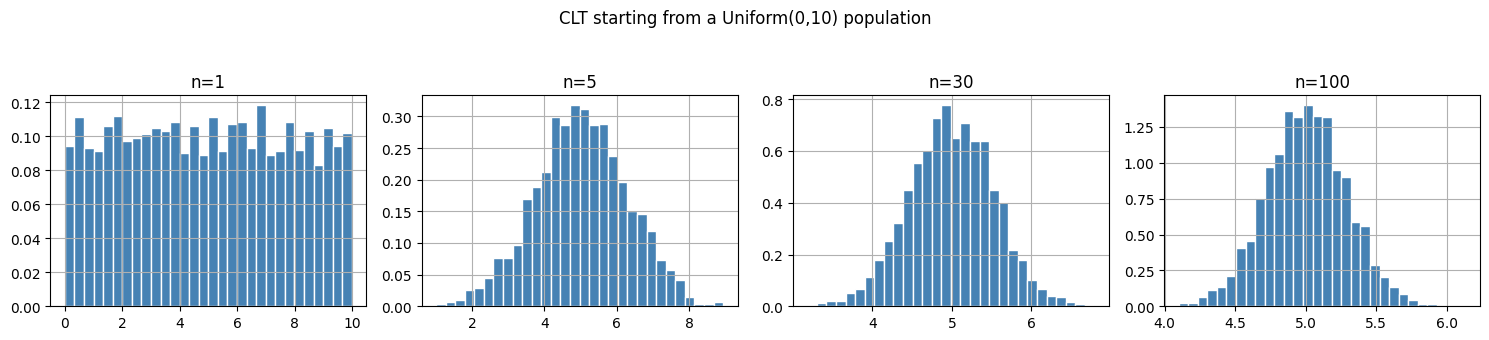

In [ ]:
# 2. Start from a population that isn't even bell-shaped at all: Uniform
clt_demo(lambda n: pd.Series(np.random.uniform(0, 10, n)), "CLT starting from a Uniform(0,10) population")

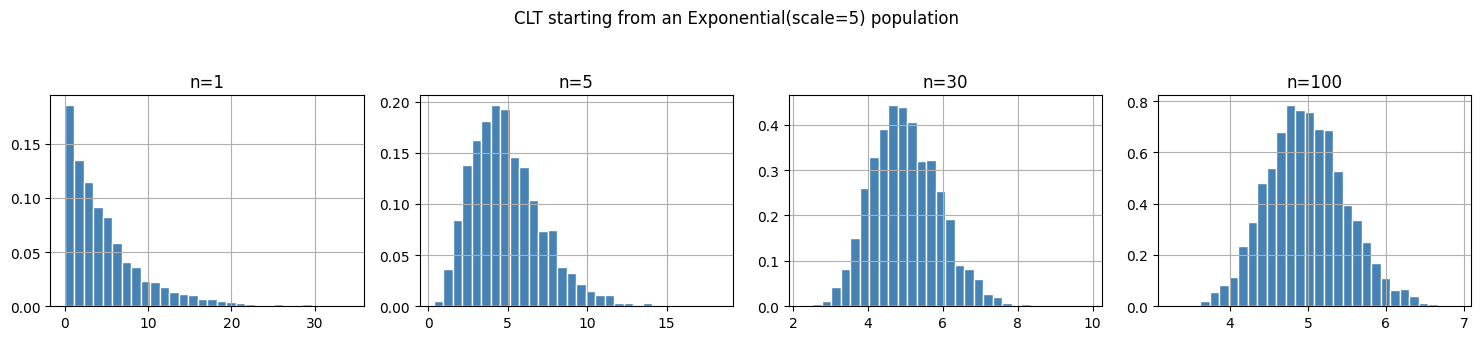

In [ ]:
# 3. Start from an Exponential distribution (also skewed, but a clean parametric case)
clt_demo(lambda n: pd.Series(np.random.exponential(scale=5, size=n)), "CLT starting from an Exponential(scale=5) population")

In every case — no matter how skewed, flat, or oddly shaped the *original* population is — by around $n=30$ the distribution of the **sample mean** already looks close to Normal. This is the CLT in action, and it's what justifies using Normal-based formulas (like confidence intervals) even when raw data isn't Normal.

### From CLT to confidence intervals

Because $\bar{X}$ is approximately Normal, a 95% confidence interval for the population mean is:

$$\bar{x} \pm 1.96 \times \frac{s}{\sqrt{n}}$$

In [ ]:
n = 50
sample = fare_population.sample(n, random_state=3)
x_bar, s = sample.mean(), sample.std(ddof=1)
se = s / np.sqrt(n)
ci_low, ci_high = x_bar - 1.96*se, x_bar + 1.96*se

print(f"Sample mean fare: {x_bar:.2f}")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
print(f"True population mean: {pop_mean:.2f}  -> {'inside' if ci_low <= pop_mean <= ci_high else 'outside'} the interval")

Sample mean fare: 37.43
95% CI: [22.38, 52.48]
True population mean: 32.20  -> inside the interval


In [ ]:
# Confirm the "95%" claim by simulation: what fraction of many such intervals actually contain the true mean?
hits = 0
n_trials = 1000
for i in range(n_trials):
    s = fare_population.sample(n, replace=True, random_state=i)
    xb, sd = s.mean(), s.std(ddof=1)
    se = sd / np.sqrt(n)
    lo, hi = xb - 1.96*se, xb + 1.96*se
    hits += (lo <= pop_mean <= hi)

print(f"Coverage: {hits}/{n_trials} = {hits/n_trials:.3f}  (should be close to 0.95)")

Coverage: 900/1000 = 0.900  (should be close to 0.95)


---
# 2. Point estimates

A **point estimate** is a single number used to estimate a population parameter — e.g. the sample mean $\bar{x}$ estimates the population mean $\mu$.

The problem: a point estimate alone doesn't tell you *how much to trust it*. Two samples of very different sizes could give the exact same mean, but the larger one deserves more confidence.

In [ ]:
fare = titanic['fare'].dropna()
age = titanic['age'].dropna()

print(f"Point estimate — mean fare: {fare.mean():.2f}")
print(f"Point estimate — mean age:  {age.mean():.2f}")
print(f"Point estimate — proportion survived: {titanic['survived'].mean():.3f}")

Point estimate — mean fare: 32.20
Point estimate — mean age:  29.70
Point estimate — proportion survived: 0.384


In [ ]:
# Illustrate the problem: same mean, very different sample sizes -> very different trust
np.random.seed(1)
small_sample = fare.sample(5)
large_sample = fare.sample(300)
print(f"Small sample (n=5)   mean: {small_sample.mean():.2f}, std: {small_sample.std():.2f}")
print(f"Large sample (n=300) mean: {large_sample.mean():.2f}, std: {large_sample.std():.2f}")
print("-> Point estimates alone don't show that the n=5 estimate is far less trustworthy.")

Small sample (n=5)   mean: 15.74, std: 9.50
Large sample (n=300) mean: 31.76, std: 47.49
-> Point estimates alone don't show that the n=5 estimate is far less trustworthy.


---
# 3. Confidence intervals for a mean

A **confidence interval (CI)** gives a *range* of plausible values for the population parameter, built from the point estimate plus a margin of error:

$$\bar{x} \pm t^{*}_{\alpha/2, \, n-1} \times \frac{s}{\sqrt{n}}$$

We use the **t-distribution** (not Normal) whenever the population standard deviation is unknown and estimated from the sample — which is almost always the case in practice. The t-distribution has heavier tails than Normal, which widens the interval to account for the extra uncertainty of also having estimated $s$.

In [ ]:
def mean_ci(sample, confidence=0.95):
    n = len(sample)
    x_bar = sample.mean()
    se = sample.std(ddof=1) / np.sqrt(n)
    t_star = stats.t.ppf((1 + confidence) / 2, df=n-1)
    margin = t_star * se
    return x_bar, x_bar - margin, x_bar + margin

sample_fare = fare.sample(50, random_state=3)
x_bar, lo, hi = mean_ci(sample_fare)
print(f"Sample mean fare: {x_bar:.2f}")
print(f"95% CI: [{lo:.2f}, {hi:.2f}]")
print(f"(True population mean fare, for comparison: {fare.mean():.2f})")

Sample mean fare: 37.43
95% CI: [22.00, 52.86]
(True population mean fare, for comparison: 32.20)


In [ ]:
# scipy makes this one line, once you have mean & standard error
se = stats.sem(sample_fare)
ci = stats.t.interval(0.95, df=len(sample_fare)-1, loc=sample_fare.mean(), scale=se)
print(f"scipy CI: [{ci[0]:.2f}, {ci[1]:.2f}]  (matches our hand-rolled version)")

scipy CI: [22.00, 52.86]  (matches our hand-rolled version)


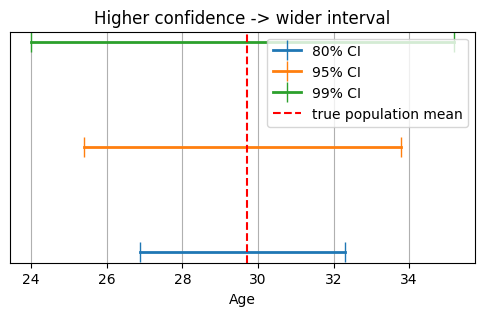

In [ ]:
# Visualize: CI for mean age, at three confidence levels
sample_age = age.sample(50, random_state=3)
fig, ax = plt.subplots(figsize=(6,3))
for i, conf in enumerate([0.80, 0.95, 0.99]):
    se_a = stats.sem(sample_age)
    lo, hi = stats.t.interval(conf, df=len(sample_age)-1, loc=sample_age.mean(), scale=se_a)
    ax.plot([lo, hi], [i, i], marker='|', markersize=15, linewidth=2, label=f'{conf:.0%} CI')
ax.axvline(age.mean(), color='red', linestyle='--', label='true population mean')
ax.set_yticks([]); ax.legend(loc='upper right'); ax.set_xlabel('Age')
ax.set_title('Higher confidence -> wider interval')
plt.show()

---
# 4. Confidence intervals for a proportion

For a proportion $\hat{p}$ (e.g. survival rate), when $n\hat{p}$ and $n(1-\hat{p})$ are both reasonably large, the Normal approximation works well:

$$\hat{p} \pm z^{*} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

In [ ]:
def proportion_ci(successes, n, confidence=0.95):
    p_hat = successes / n
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    z_star = stats.norm.ppf((1 + confidence) / 2)
    margin = z_star * se
    return p_hat, p_hat - margin, p_hat + margin

sample_titanic = titanic.sample(100, random_state=3)
n_survived = sample_titanic['survived'].sum()
n_total = len(sample_titanic)

p_hat, lo, hi = proportion_ci(n_survived, n_total)
print(f"Sample survival rate: {p_hat:.3f}")
print(f"95% CI: [{lo:.3f}, {hi:.3f}]")
print(f"(True population survival rate: {titanic['survived'].mean():.3f})")

Sample survival rate: 0.390
95% CI: [0.294, 0.486]
(True population survival rate: 0.384)


---
# 5. What does "95% confidence" actually mean?

**It does NOT mean** "there's a 95% chance the true mean is in this specific interval." Once computed, an interval either contains the true value or it doesn't — there's no probability left. It **does mean**: *if we repeated this sampling process many times, about 95% of the resulting intervals would contain the true population parameter.* Let's verify that by simulation.

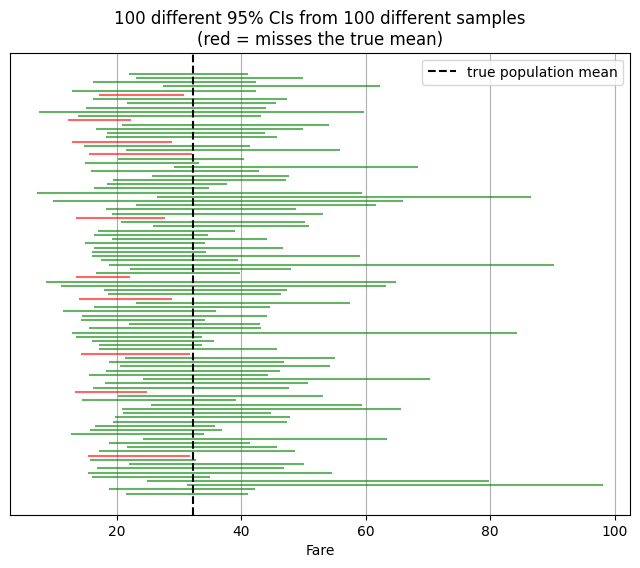

Out of 500 simulated intervals, 446 (89.2%) contained the true mean.


In [ ]:
true_mean = fare.mean()
n = 40
n_trials = 500
hits = 0
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(n_trials):
    s = fare.sample(n, replace=True, random_state=i)
    se = stats.sem(s)
    lo, hi = stats.t.interval(0.95, df=n-1, loc=s.mean(), scale=se)
    contains = lo <= true_mean <= hi
    hits += contains
    if i < 100:   # only plot the first 100 for readability
        ax.plot([lo, hi], [i, i], color='green' if contains else 'red', alpha=0.6)

ax.axvline(true_mean, color='black', linestyle='--', label='true population mean')
ax.set_yticks([]); ax.set_xlabel('Fare'); ax.legend()
ax.set_title(f'100 different 95% CIs from 100 different samples\n(red = misses the true mean)')
plt.show()

print(f"Out of {n_trials} simulated intervals, {hits} ({hits/n_trials:.1%}) contained the true mean.")

---
# 6. Sample size & margin of error

Margin of error shrinks with $\sqrt{n}$ — to *halve* your margin of error, you need **4 times** as much data, not 2 times. This is why polls and studies quote sample sizes: it tells you how tight their uncertainty really is.

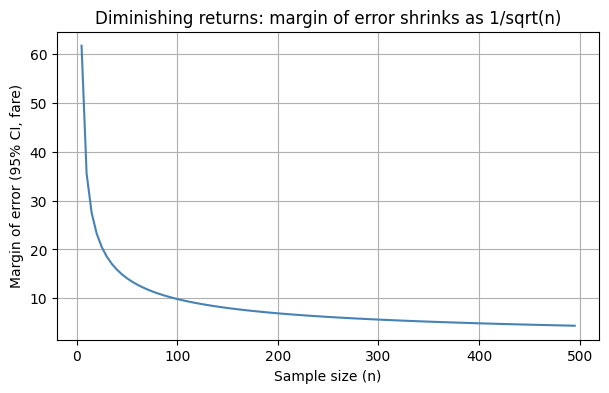

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))
ns = np.arange(5, 500, 5)
margins = [stats.t.ppf(0.975, df=n-1) * fare.std() / np.sqrt(n) for n in ns]
ax.plot(ns, margins, color='steelblue')
ax.set_xlabel('Sample size (n)'); ax.set_ylabel('Margin of error (95% CI, fare)')
ax.set_title('Diminishing returns: margin of error shrinks as 1/sqrt(n)')
plt.show()

In [ ]:
# How large a sample do we need for a target margin of error on a proportion?
def required_n(margin, p_guess=0.5, confidence=0.95):
    z_star = stats.norm.ppf((1 + confidence) / 2)
    return int(np.ceil((z_star**2 * p_guess * (1-p_guess)) / margin**2))

for margin in [0.10, 0.05, 0.02, 0.01]:
    print(f"Margin of error = {margin:.0%}  ->  need n = {required_n(margin)}")
print("\n-> Halving the margin of error (0.10 -> 0.05) roughly quadruples the required sample size.")

Margin of error = 10%  ->  need n = 97
Margin of error = 5%  ->  need n = 385
Margin of error = 2%  ->  need n = 2401
Margin of error = 1%  ->  need n = 9604

-> Halving the margin of error (0.10 -> 0.05) roughly quadruples the required sample size.


---
# 7. Exercises

1. Compute a 90% confidence interval for the mean `age` using a sample of 30 passengers. How does its width compare to a 95% CI on the same sample?
2. Compute a 95% confidence interval for the proportion of passengers travelling in 3rd class, using a random sample of 150 passengers.
3. Run the "what does 95% confidence mean" simulation (Section 5) but with `n=10` instead of `n=40`. Does the empirical coverage stay close to 95%? What does this suggest about the t-distribution's small-sample correction?
4. Using `required_n`, how large a sample would you need to estimate a proportion to within a 3% margin of error at 99% confidence instead of 95%?
5. **Challenge**: The proportion CI formula in Section 4 relies on a Normal approximation that can break down for small `n` or extreme `p`. Look up the **Wilson score interval** and compare it to our simple formula for a small, skewed sample (e.g. 8 successes out of 10 trials).


# Lecture 3.2.2  Hypothesis Testing, p-values & Statistical Significance
### Statistics & Quantitative Methods for Data Science

Last class we built confidence intervals — ranges of plausible values. This class asks a sharper question: **is there evidence for a specific claim**, e.g. "fare differed between survivors and non-survivors" or "gender and survival are related"?

**This notebook:**
1. The logic of hypothesis testing (H0, H1, p-values)
2. Type I & Type II errors
3. One-sample and two-sample t-tests
4. Paired t-test
5. Chi-square test of independence
6. One-way ANOVA
7. Statistical vs. practical significance
8. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


---
# 1. The logic of hypothesis testing

1. State a **null hypothesis** $H_0$ — the "nothing interesting is happening" baseline (e.g. "mean fare is the same for survivors and non-survivors").
2. State an **alternative hypothesis** $H_1$ — what you suspect instead (e.g. "mean fare differs").
3. Compute a **test statistic** from the data that measures how far the data is from what $H_0$ predicts.
4. Compute a **p-value**: *if $H_0$ were true, how likely is a result this extreme (or more extreme) just by random chance?*
5. Compare the p-value to a significance threshold $\alpha$ (conventionally 0.05). If $p < \alpha$, **reject $H_0$**.

**Crucial nuance**: a small p-value doesn't "prove $H_1$" — it means the data would be surprising *if $H_0$ were true*. We never "accept $H_0$" either; we only ever fail to reject it.

---
# 2. Type I & Type II errors

| | $H_0$ actually true | $H_0$ actually false |
|---|---|---|
| **Reject $H_0$** | Type I error (false positive), rate = $\alpha$ | Correct! |
| **Fail to reject $H_0$** | Correct! | Type II error (false negative), rate = $\beta$ |

**Statistical power** = $1-\beta$ = probability of correctly detecting a real effect. Power increases with larger sample sizes and larger true effect sizes.

In [ ]:
# Simulate Type I error rate directly: if H0 is TRUE (two samples really drawn from the same population),
# how often does a t-test wrongly reject H0 at alpha=0.05, just by chance?
false_positives = 0
n_sims = 2000
population = titanic['fare'].dropna().values

for i in range(n_sims):
    rng = np.random.default_rng(i)
    sample_a = rng.choice(population, size=40, replace=True)
    sample_b = rng.choice(population, size=40, replace=True)   # same population -> H0 is TRUE
    _, p = stats.ttest_ind(sample_a, sample_b)
    if p < 0.05:
        false_positives += 1

print(f"False positive rate: {false_positives/n_sims:.3f}  (should be close to alpha=0.05)")

False positive rate: 0.041  (should be close to alpha=0.05)


---
# 3. One-sample and two-sample t-tests

**One-sample t-test**: does the sample mean differ from a specific known value?
**Two-sample (independent) t-test**: do two independent groups have different means?

In [ ]:
# One-sample: was the average fare 30, historically claimed? Test against our data.
fare = titanic['fare'].dropna()
t_stat, p_val = stats.ttest_1samp(fare, popmean=30)
print(f"One-sample t-test (H0: mean fare = 30)")
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
print("Reject H0" if p_val < 0.05 else "Fail to reject H0", f"at alpha=0.05 (sample mean = {fare.mean():.2f})")

One-sample t-test (H0: mean fare = 30)
t = 1.324, p = 0.1858
Fail to reject H0 at alpha=0.05 (sample mean = 32.20)


In [ ]:
# Two-sample: did survivors pay a different average fare than non-survivors?
fare_survived = titanic.loc[titanic.survived==1, 'fare'].dropna()
fare_died     = titanic.loc[titanic.survived==0, 'fare'].dropna()

# Welch's t-test (equal_var=False) doesn't assume the two groups have equal variance -- safer default
t_stat, p_val = stats.ttest_ind(fare_survived, fare_died, equal_var=False)
print(f"Two-sample t-test: mean fare, survived vs died")
print(f"Survived mean: {fare_survived.mean():.2f}   Died mean: {fare_died.mean():.2f}")
print(f"t = {t_stat:.3f}, p = {p_val:.2e}")
print("Reject H0: fares differ significantly." if p_val < 0.05 else "Fail to reject H0.")

Two-sample t-test: mean fare, survived vs died
Survived mean: 48.40   Died mean: 22.12
t = 6.839, p = 2.70e-11
Reject H0: fares differ significantly.


/tmp/ipykernel_119/3453528103.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([fare_died, fare_survived], labels=['Died', 'Survived'])


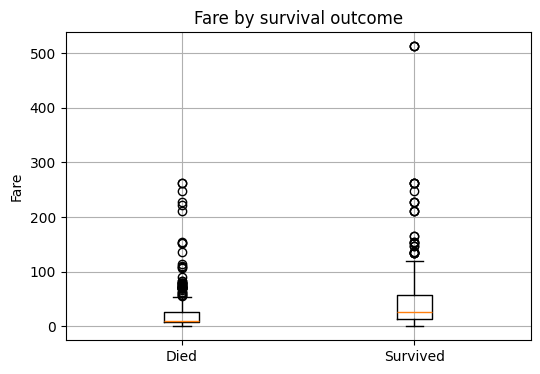

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.boxplot([fare_died, fare_survived], labels=['Died', 'Survived'])
ax.set_ylabel('Fare'); ax.set_title('Fare by survival outcome')
plt.show()

---
# 5. Chi-square test of independence

Used for **two categorical variables**: are they associated, or independent? Compares observed counts in a contingency table to the counts we'd *expect* if the variables were unrelated.

$$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$

In [ ]:
contingency = pd.crosstab(titanic['sex'], titanic['survived'])
print("Observed counts:")
print(contingency)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square = {chi2:.2f}, dof = {dof}, p = {p_val:.2e}")
print("\nExpected counts under independence:")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1))
print("\nReject H0: sex and survival are significantly associated." if p_val < 0.05 else "Fail to reject H0.")

Observed counts:
survived    0    1
sex               
female     81  233
male      468  109

Chi-square = 260.72, dof = 1, p = 1.20e-58

Expected counts under independence:
survived      0      1
sex                   
female    193.5  120.5
male      355.5  221.5

Reject H0: sex and survival are significantly associated.


In [ ]:
# Another one: is passenger class associated with embarkation town?
ct2 = pd.crosstab(titanic['pclass'], titanic['embark_town'])
chi2, p_val, dof, expected = stats.chi2_contingency(ct2)
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p = {p_val:.2e}")
print("Class and embarkation town are significantly associated." if p_val < 0.05 else "No significant association.")

Chi-square = 123.75, dof = 4, p = 8.44e-26
Class and embarkation town are significantly associated.


---
# 6. One-way ANOVA

t-tests compare **two** group means. When comparing **three or more** groups at once, use **ANOVA** (Analysis of Variance) — it tests whether *at least one* group mean differs, without inflating the false-positive rate the way running many pairwise t-tests would.

$H_0$: all group means are equal. $H_1$: at least one differs.

In [ ]:
fare_by_class = [titanic.loc[titanic.pclass==c, 'fare'].dropna() for c in [1,2,3]]

f_stat, p_val = stats.f_oneway(*fare_by_class)
print(f"F-statistic = {f_stat:.2f}, p = {p_val:.2e}")
print("Reject H0: mean fare differs significantly across at least one class." if p_val < 0.05 else "Fail to reject H0.")

for c, f in zip([1,2,3], fare_by_class):
    print(f"  Class {c}: mean fare = {f.mean():.2f}, n = {len(f)}")

F-statistic = 242.34, p = 1.03e-84
Reject H0: mean fare differs significantly across at least one class.
  Class 1: mean fare = 84.15, n = 216
  Class 2: mean fare = 20.66, n = 184
  Class 3: mean fare = 13.68, n = 491


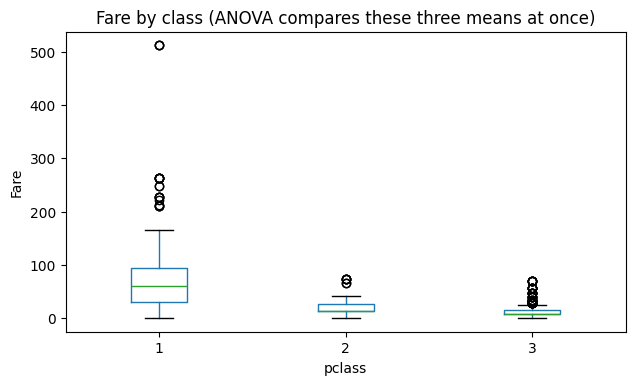

In [ ]:
titanic.boxplot(column='fare', by='pclass', grid=False)
plt.title('Fare by class (ANOVA compares these three means at once)')
plt.suptitle(''); plt.ylabel('Fare')
plt.show()

> ANOVA tells you *that* a difference exists somewhere, but not *which* pairs differ. Follow-up "post-hoc" tests (e.g. Tukey's HSD) are used to pin that down — worth looking into if this comes up in your own analyses.

---
# 7. Statistical vs. practical significance

A result can be **statistically significant** (very unlikely under $H_0$) yet **practically trivial** — especially with large sample sizes, where even a tiny, uninteresting difference can produce a tiny p-value. Always report and think about the **effect size**, not just the p-value.

In [ ]:
# Demonstrate: with a huge sample, even a trivially small difference becomes "significant"
np.random.seed(0)
group_a = np.random.normal(50.0, 10, 100_000)
group_b = np.random.normal(50.1, 10, 100_000)   # a difference of 0.1 -- practically meaningless

t_stat, p_val = stats.ttest_ind(group_a, group_b)
print(f"Mean difference: {group_b.mean()-group_a.mean():.3f}")
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
print("'Significant' by p-value, but is a 0.1-unit difference practically meaningful? Almost certainly not.")

# Effect size: Cohen's d puts the difference in units of standard deviation
pooled_std = np.sqrt((group_a.std()**2 + group_b.std()**2) / 2)
cohens_d = (group_b.mean() - group_a.mean()) / pooled_std
print(f"Cohen's d = {cohens_d:.4f}  (by convention: 0.2=small, 0.5=medium, 0.8=large -- this is negligible)")

Mean difference: 0.135
t = -3.028, p = 0.0025
'Significant' by p-value, but is a 0.1-unit difference practically meaningful? Almost certainly not.
Cohen's d = 0.0135  (by convention: 0.2=small, 0.5=medium, 0.8=large -- this is negligible)


---
# 8. Exercises

1. Run a one-sample t-test on `age`, testing $H_0$: mean age = 30. State your conclusion.
2. Run a two-sample t-test comparing `age` between 1st class and 3rd class passengers. Are they significantly different?
3. Build a contingency table of `survived` vs `pclass` and run a chi-square test. State the conclusion in plain English.
4. Run a one-way ANOVA comparing `age` across the three `pclass` groups. Which class has the highest mean age?
5. Compute Cohen's d for the fare difference between survivors and non-survivors (Section 3). Is the statistically significant difference also a practically large one?
6. **Challenge**: Simulate the Type II error rate (rather than Type I): draw `sample_a` and `sample_b` from populations with a genuinely different mean (e.g. shift `sample_b` by +5), and see how often the t-test *fails* to detect it at `n=10` vs `n=100`. What does this tell you about statistical power and sample size?
